# Experimento de Rendimiento — K-Means Serial vs Paralelo
**Fernando Barba y Nicolas Robles**

---
### Estructura esperada del directorio
```
├── kmeans_serial.cpp
├── kmeans_serial.exe
├── kmeans_paralelo.cpp
├── kmeans_paralelo.exe
├── datos
    ├── 100000_data_2d.csv
    ├── 100000_data_3d.csv
    └── ... (resto de CSVs)
└── experimento.ipynb
```

## 1. Imports y configuración del experimento

In [1]:
import subprocess
import re
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display

# ─── Parámetros del experimento ──────────────────────────────────────────────
K            = 8
REPETICIONES = 10
CORES        = 16
PUNTOS_LIST = [100000, 200000, 300000, 400000, 600000, 800000, 1000000]
DIMS_LIST   = [2, 3]
HILOS_LIST  = [1, CORES // 2, CORES, CORES * 2,]

# ─── Ejecutables y rutas ─────────────────────────────────────────────────────
EXE_SERIAL   = "./kmeans_serial.exe"
EXE_PARALELO = "./kmeans_paralelo.exe"
RESULTADOS_DIR = "resultados"

# ─── Patrón para extraer el tiempo de la salida del programa ─────────────────
PATRON_TIEMPO = re.compile(r"Tiempo de K-Means:\s*([\d.]+)\s*segundos\.")

os.makedirs(RESULTADOS_DIR, exist_ok=True)

print("Configuración del experimento:")
print(f"  k            = {K}")
print(f"  Repeticiones = {REPETICIONES}")
print(f"  Cores        = {CORES}")
print(f"  Hilos        = {HILOS_LIST}")
print(f"  Puntos       = {PUNTOS_LIST}")
print(f"  Dims         = {DIMS_LIST}")
total = len(DIMS_LIST) * len(PUNTOS_LIST) * len(HILOS_LIST) * REPETICIONES
print(f"  Total corridas: {total}")

Configuración del experimento:
  k            = 8
  Repeticiones = 10
  Cores        = 16
  Hilos        = [1, 8, 16, 32]
  Puntos       = [100000, 200000, 300000, 400000, 600000, 800000, 1000000]
  Dims         = [2, 3]
  Total corridas: 560


## 2. Verificación de ejecutables y archivos de entrada

In [2]:
# ─── Verificar ejecutables ────────────────────────────────────────────────────
faltan = False

for exe in [EXE_SERIAL, EXE_PARALELO]:
    if not os.path.isfile(exe):
        faltan = True
        break

if faltan:
    print("Faltan ejecutables, no se podrá correr el archivo")

# ─── Verificar CSVs de entrada ────────────────────────────────────────────────
faltantes = []

for dims in DIMS_LIST:
    for puntos in PUNTOS_LIST:
        nombre = os.path.join("datos", f"{puntos}_data_{dims}d.csv")
        if not os.path.isfile(nombre):
            faltantes.append(nombre)

if faltantes:
    print(f"\Faltan {len(faltantes)} archivos. Se saltarán esas configuraciones.")
else:
    print("\Todo listo para correr el experimento.")

\Todo listo para correr el experimento.


## 3. Funciones auxiliares

In [3]:
def extraer_tiempo(salida_texto): # Extrae el tiempo en segundos de la salida del programa
    match = PATRON_TIEMPO.search(salida_texto)
    return float(match.group(1)) if match else None


def correr_programa(puntos, dims, hilos, rep): # Ejecuta el programa (serial si hilos==1, paralelo si hilos>1). Regresa el tiempo en segundos
    entrada = os.path.join("datos", f"{puntos}_data_{dims}d.csv")
    tag     = "serial" if hilos == 1 else f"par_h{hilos}"
    salida  = os.path.join(RESULTADOS_DIR, f"clusters_{puntos}_{dims}d_{tag}_rep{rep}.csv")

    if hilos == 1:
        cmd = [EXE_SERIAL,   entrada, str(K), str(dims),              salida] # ./kmeans_serial   entrada.csv  K  dims          salida.csv
    else:
        cmd = [EXE_PARALELO, entrada, str(K), str(dims), str(hilos),  salida] # ./kmeans_paralelo entrada.csv  K  dims  hilos   salida.csv

    try:
        resultado = subprocess.run(
            cmd, capture_output=True, text=True, timeout=300
        )
        return extraer_tiempo(resultado.stdout + resultado.stderr)
    except subprocess.TimeoutExpired:
        print(f"    [TIMEOUT] {cmd}")
        return None
    except Exception as e:
        print(f"    [ERROR] {e}")
        return None

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## 4. Correr el experimento
Esta celda tarda >30 minutos

In [ ]:
filas        = []
t_inicio     = time.time()

for dims in DIMS_LIST:
    for puntos in PUNTOS_LIST:

        entrada = f"{puntos}_data_{dims}d.csv"
        if not os.path.isfile(entrada):
            print(f"[SKIP] {entrada} no encontrado")
            continue

        print(f"\n{'─'*55}")
        print(f"  dims={dims}D   puntos={puntos:,}")
        print(f"{'─'*55}")

        for hilos in HILOS_LIST:
            tiempos_rep = []

            for rep in range(1, REPETICIONES + 1):
                t = correr_programa(puntos, dims, hilos, rep)

                if t is not None:
                    tiempos_rep.append(t)
                    filas.append({
                        "dims":     dims,
                        "puntos":   puntos,
                        "hilos":    hilos,
                        "rep":      rep,
                        "tiempo_s": t,
                    })

            # Resumen de esta configuración
            etiqueta = "serial  " if hilos == 1 else f"paralelo h={hilos:<2}"
            if tiempos_rep:
                promedio = sum(tiempos_rep) / len(tiempos_rep)
                print(f"  {etiqueta}  prom={promedio:.4f}s  "
                      f"({len(tiempos_rep)}/{REPETICIONES} OK)  ")
            else:
                print(f"  {etiqueta}  Todas las corridas fallaron")

t_total = time.time() - t_inicio
print(f"\n{'='*55}")
print(f"  Experimento terminado en {t_total/60:.1f} minutos")
print(f"{'='*55}")

# Guardar tiempos crudos
df = pd.DataFrame(filas)
ruta_tiempos = os.path.join(RESULTADOS_DIR, "tiempos.csv")
df.to_csv(ruta_tiempos, index=False)
print(f"\nTiempos guardados en: {ruta_tiempos}")
display(df.head(10))


───────────────────────────────────────────────────────
  dims=2D   puntos=100,000
───────────────────────────────────────────────────────
  serial    prom=0.1394s  (10/10 OK)  [10/560]
  paralelo h=8   prom=0.0963s  (10/10 OK)  [20/560]
  paralelo h=16  prom=0.1299s  (10/10 OK)  [30/560]
  paralelo h=32  prom=0.1312s  (10/10 OK)  [40/560]

───────────────────────────────────────────────────────
  dims=2D   puntos=200,000
───────────────────────────────────────────────────────
  serial    prom=0.2805s  (10/10 OK)  [50/560]
  paralelo h=8   prom=0.1575s  (10/10 OK)  [60/560]
  paralelo h=16  prom=0.2368s  (10/10 OK)  [70/560]
  paralelo h=32  prom=0.3156s  (10/10 OK)  [80/560]

───────────────────────────────────────────────────────
  dims=2D   puntos=300,000
───────────────────────────────────────────────────────
  serial    prom=0.3972s  (10/10 OK)  [90/560]
  paralelo h=8   prom=0.1798s  (10/10 OK)  [100/560]
  paralelo h=16  prom=0.1860s  (10/10 OK)  [110/560]
  paralelo h=32  prom

,dims,puntos,hilos,rep,tiempo_s
0,2,100000,1,1,0.173794
1,2,100000,1,2,0.178792
2,2,100000,1,3,0.227842
3,2,100000,1,4,0.069041
4,2,100000,1,5,0.071370
5,2,100000,1,6,0.170078
6,2,100000,1,7,0.152252
7,2,100000,1,8,0.231540
8,2,100000,1,9,0.055569
9,2,100000,1,10,0.063553


## 5. Calcular speedup y promedios

In [9]:
# ─── Promediar las 10 repeticiones ───────────────────────────────────────────
promedios = (
    df.groupby(["dims", "puntos", "hilos"])["tiempo_s"]
    .mean()
    .reset_index()
    .rename(columns={"tiempo_s": "tiempo_promedio"})
)

# ─── Calcular speedup = T_serial / T_paralelo ────────────────────────────────
filas_speedup = []
for dims in promedios["dims"].unique():
    for puntos in promedios["puntos"].unique():
        subset  = promedios[(promedios["dims"] == dims) & (promedios["puntos"] == puntos)]
        serial  = subset[subset["hilos"] == 1]
        if serial.empty:
            continue
        t_serial = serial["tiempo_promedio"].values[0]

        for _, row in subset.iterrows():
            filas_speedup.append({
                "dims":            dims,
                "puntos":          int(row["puntos"]),
                "hilos":           int(row["hilos"]),
                "tiempo_promedio": row["tiempo_promedio"],
                "speedup":         t_serial / row["tiempo_promedio"],
                "eficiencia":      (t_serial / row["tiempo_promedio"]) / row["hilos"],
            })

speedup_df = pd.DataFrame(filas_speedup)

# Guardar tabla de speedup
ruta_speedup = os.path.join(RESULTADOS_DIR, "speedup.csv")
speedup_df.to_csv(ruta_speedup, index=False)
print(f"Speedup guardado en: {ruta_speedup}\n")

# Mostrar tabla
pd.set_option("display.float_format", "{:.4f}".format)
display(speedup_df)

Speedup guardado en: resultados\speedup.csv



,dims,puntos,hilos,tiempo_promedio,speedup,eficiencia
0,2,100000,1,0.1394,1.0000,1.0000
1,2,100000,8,0.0963,1.4478,0.1810
2,2,100000,16,0.1299,1.0732,0.0671
3,2,100000,32,0.1312,1.0626,0.0332
4,2,200000,1,0.2805,1.0000,1.0000
5,2,200000,8,0.1575,1.7811,0.2226
6,2,200000,16,0.2368,1.1845,0.0740
7,2,200000,32,0.3156,0.8888,0.0278
8,2,300000,1,0.3972,1.0000,1.0000
9,2,300000,8,0.1798,2.2096,0.2762


## 6. Gráfica de Speedup

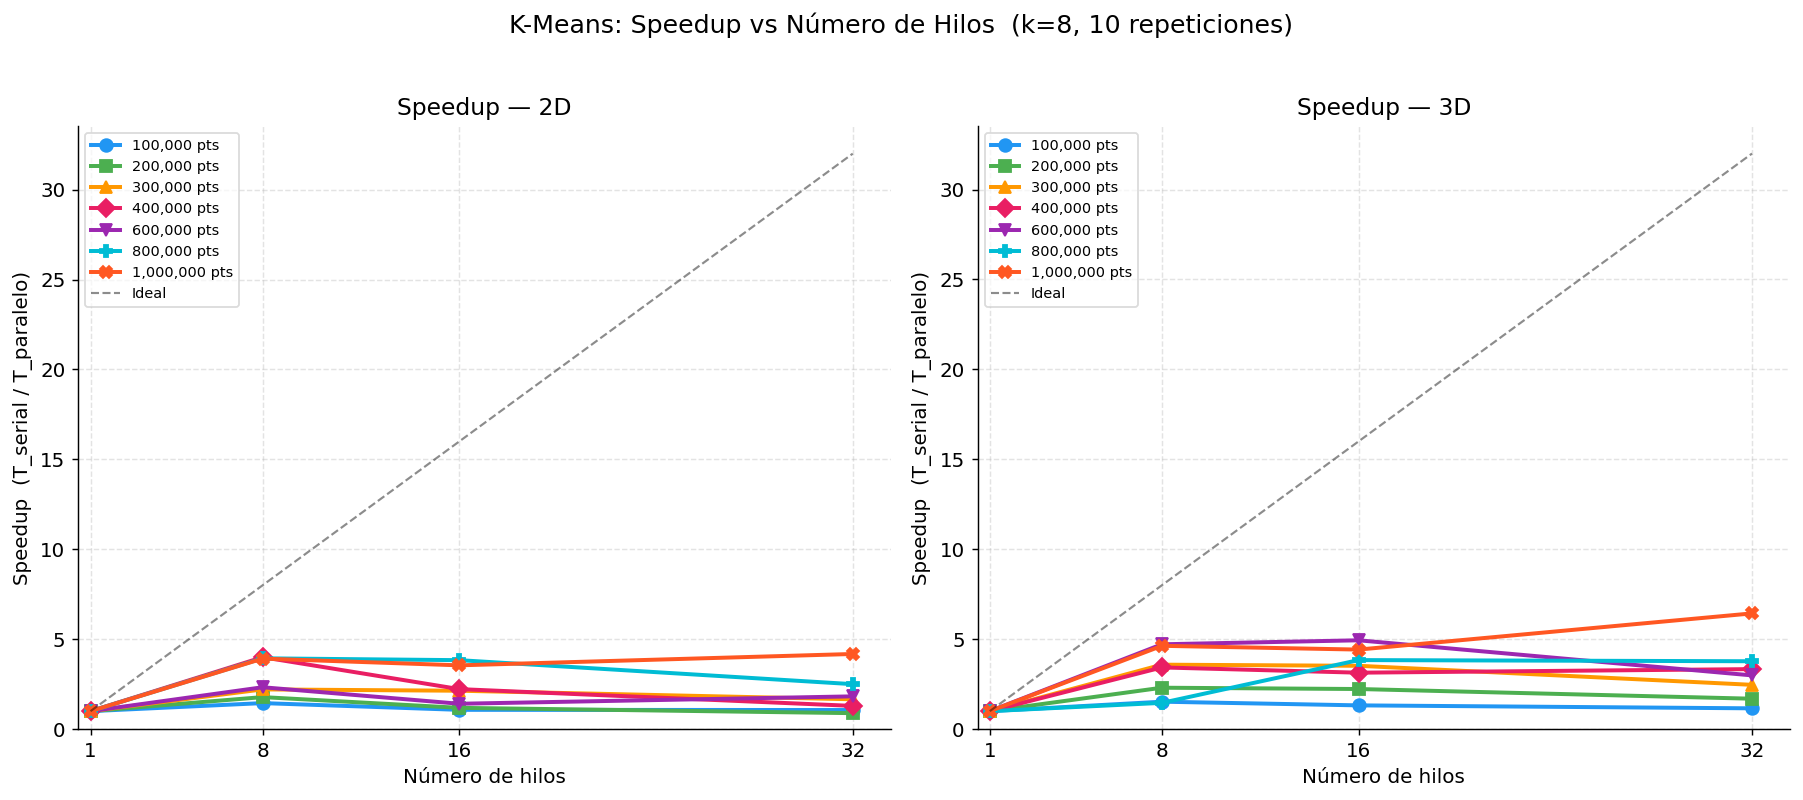

Guardada: resultados\grafica_speedup.png


In [10]:
COLORES    = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#00BCD4", "#FF5722"]
MARCADORES = ["o", "s", "^", "D", "v", "P", "X"]

plt.rcParams.update({
    "figure.dpi":        130,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "grid.linestyle":    "--",
    "lines.linewidth":   2.2,
    "lines.markersize":  7,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, dims in enumerate([2, 3]):
    ax   = axes[idx]
    data = speedup_df[speedup_df["dims"] == dims]
    puntos_list = sorted(data["puntos"].unique())
    max_hilos   = data["hilos"].max()

    for i, puntos in enumerate(puntos_list):
        sub = data[data["puntos"] == puntos].sort_values("hilos")
        ax.plot(
            sub["hilos"], sub["speedup"],
            color=COLORES[i % len(COLORES)],
            marker=MARCADORES[i % len(MARCADORES)],
            label=f"{puntos:,} pts",
        )

    # Línea de speedup ideal
    ax.plot([1, max_hilos], [1, max_hilos], "k--",
            linewidth=1.2, alpha=0.45, label="Ideal")

    ax.set_title(f"Speedup — {dims}D", fontsize=13)
    ax.set_xlabel("Número de hilos")
    ax.set_ylabel("Speedup  (T_serial / T_paralelo)")
    ax.set_xlim(left=0.5)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(ticker.FixedLocator(HILOS_LIST))
    ax.legend(fontsize=8, loc="upper left", framealpha=0.7)

fig.suptitle(
    f"K-Means: Speedup vs Número de Hilos  (k={K}, {REPETICIONES} repeticiones)",
    fontsize=14, y=1.02
)
plt.tight_layout()
ruta = os.path.join(RESULTADOS_DIR, "grafica_speedup.png")
plt.savefig(ruta, bbox_inches="tight")
plt.show()
print(f"Guardada: {ruta}")

## 7. Gráfica de Tiempo de Ejecución

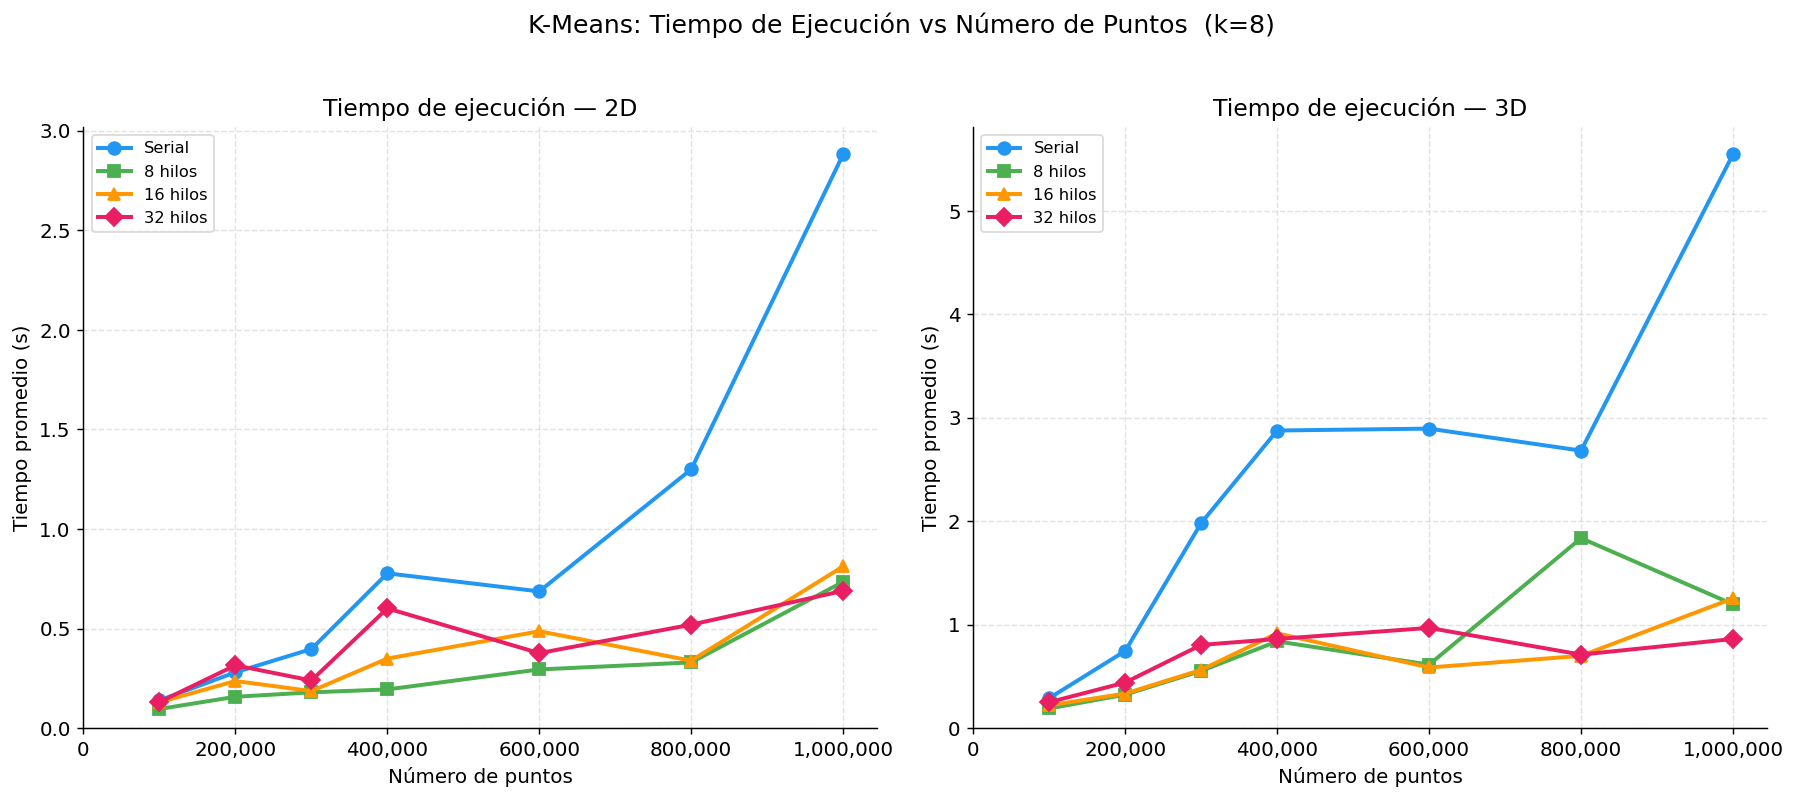

Guardada: resultados\grafica_tiempo.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, dims in enumerate([2, 3]):
    ax   = axes[idx]
    data = speedup_df[speedup_df["dims"] == dims]
    hilos_list = sorted(data["hilos"].unique())

    for i, hilos in enumerate(hilos_list):
        sub   = data[data["hilos"] == hilos].sort_values("puntos")
        label = "Serial" if hilos == 1 else f"{hilos} hilos"
        ax.plot(
            sub["puntos"], sub["tiempo_promedio"],
            color=COLORES[i % len(COLORES)],
            marker=MARCADORES[i % len(MARCADORES)],
            label=label,
        )

    ax.set_title(f"Tiempo de ejecución — {dims}D", fontsize=13)
    ax.set_xlabel("Número de puntos")
    ax.set_ylabel("Tiempo promedio (s)")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    ax.legend(fontsize=9, loc="upper left", framealpha=0.7)

fig.suptitle(
    f"K-Means: Tiempo de Ejecución vs Número de Puntos  (k={K})",
    fontsize=14, y=1.02
)
plt.tight_layout()
ruta = os.path.join(RESULTADOS_DIR, "grafica_tiempo.png")
plt.savefig(ruta, bbox_inches="tight")
plt.show()
print(f"Guardada: {ruta}")

## 8. Gráfica de Eficiencia Paralela

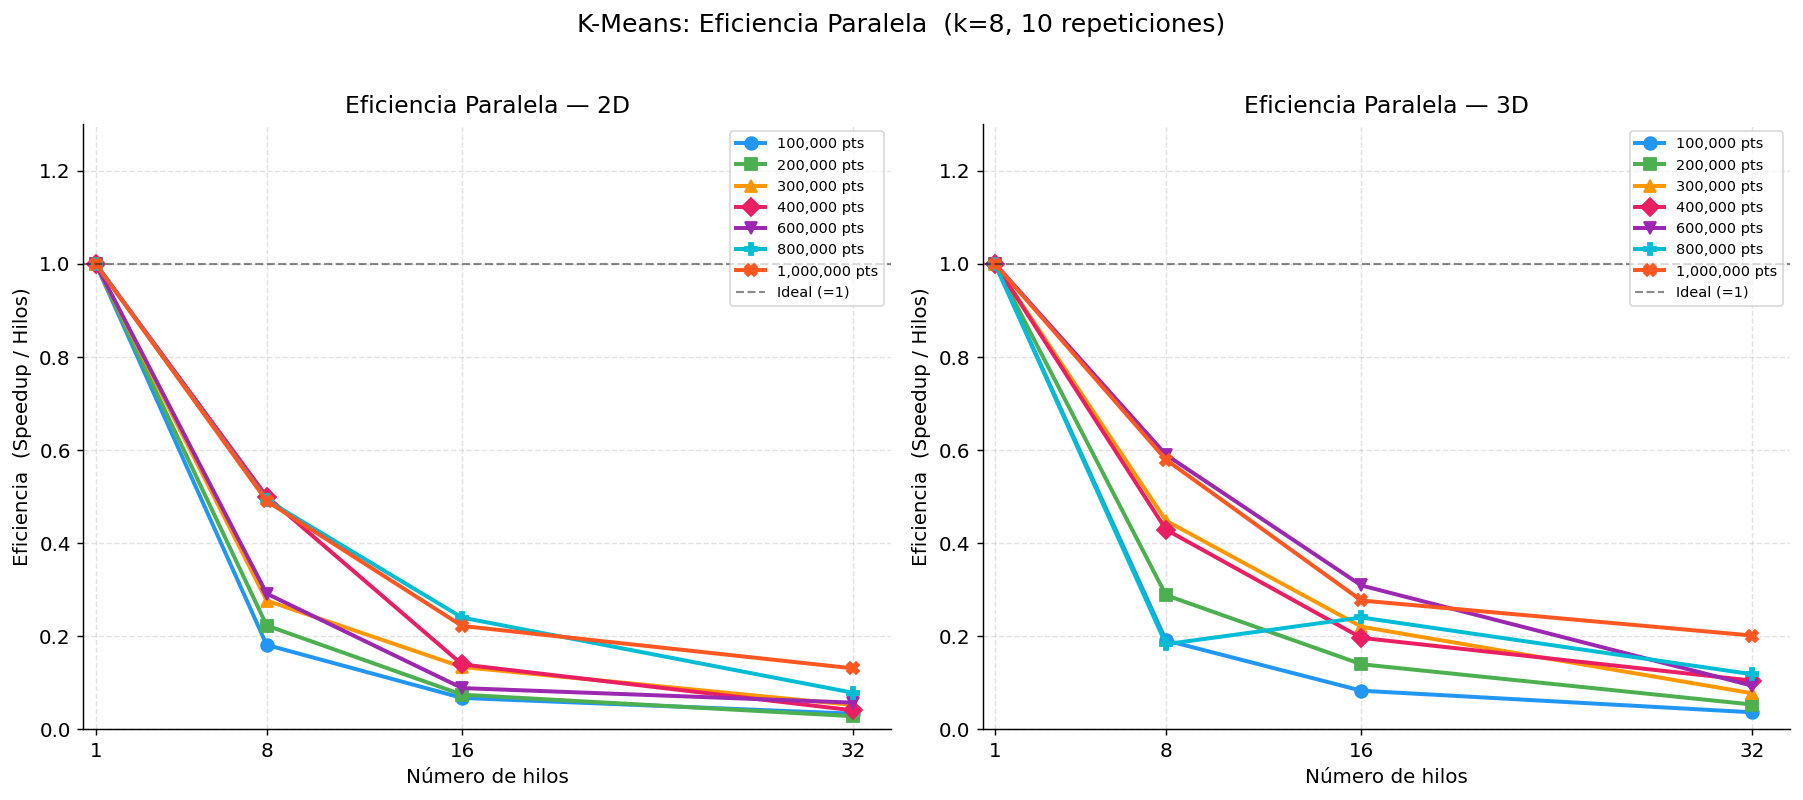

Guardada: resultados\grafica_eficiencia.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, dims in enumerate([2, 3]):
    ax   = axes[idx]
    data = speedup_df[speedup_df["dims"] == dims].copy()
    puntos_list = sorted(data["puntos"].unique())

    for i, puntos in enumerate(puntos_list):
        sub = data[data["puntos"] == puntos].sort_values("hilos")
        ax.plot(
            sub["hilos"], sub["eficiencia"],
            color=COLORES[i % len(COLORES)],
            marker=MARCADORES[i % len(MARCADORES)],
            label=f"{puntos:,} pts",
        )

    # Línea de eficiencia ideal = 1.0
    ax.axhline(y=1.0, color="black", linestyle="--",
               linewidth=1.2, alpha=0.45, label="Ideal (=1)")

    ax.set_title(f"Eficiencia Paralela — {dims}D", fontsize=13)
    ax.set_xlabel("Número de hilos")
    ax.set_ylabel("Eficiencia  (Speedup / Hilos)")
    ax.set_xlim(left=0.5)
    ax.set_ylim(0, 1.3)
    ax.xaxis.set_major_locator(ticker.FixedLocator(HILOS_LIST))
    ax.legend(fontsize=8, loc="upper right", framealpha=0.7)

fig.suptitle(
    f"K-Means: Eficiencia Paralela  (k={K}, {REPETICIONES} repeticiones)",
    fontsize=14, y=1.02
)
plt.tight_layout()
ruta = os.path.join(RESULTADOS_DIR, "grafica_eficiencia.png")
plt.savefig(ruta, bbox_inches="tight")
plt.show()
print(f"Guardada: {ruta}")